In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sqlite3
from scipy.stats import ttest_ind
import scipy.stats as stats
warnings.filterwarnings('ignore')

### Loading the dataset

In [2]:
conn = sqlite3.connect('inventory.db')

df = pd.read_sql_query('select * from vendor_sales_summary',conn)
df.head()

,vendor_number,vendor_name,brand,description,purchase_price,actual_price,volume,total_purchase_quantity,total_purchase_dollars,total_sales_quantity,total_sales_dollars,total_sales_price,total_excise_tax,freight_cost,gross_profit,profit_margin,stock_turnover,sales_purchase_ratio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,5101919.51,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4819073.49,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,4538120.60,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,4475972.88,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,4223107.62,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897


# Exploratory data analysis
* Previously, we examined the various tables in the database to identify key variables , understand their relationship, and determine which ones should be included in the final analysis.
* In this phase of EDA, we will analyze the resultant table to gain insights into the distribution of each column. This will help us understand data patterns, identify anamolies, and ensure data quality before proceeding with further analysis.

In [3]:
# summary statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
vendor_number,10692.0,1.065065e+04,18753.519148,2.00,3951.000000,7153.000000,9552.000000,2.013590e+05
brand,10692.0,1.803923e+04,12662.187074,58.00,5793.500000,18761.500000,25514.250000,9.063100e+04
purchase_price,10692.0,2.438530e+01,109.269375,0.36,6.840000,10.455000,19.482500,5.681810e+03
actual_price,10692.0,3.564367e+01,148.246016,0.49,10.990000,15.990000,28.990000,7.499990e+03
volume,10692.0,8.473605e+02,664.309212,50.00,750.000000,750.000000,750.000000,2.000000e+04
total_purchase_quantity,10692.0,3.140887e+03,11095.086769,1.00,36.000000,262.000000,1975.750000,3.376600e+05
total_purchase_dollars,10692.0,3.010669e+04,123067.799627,0.71,453.457500,3655.465000,20738.245000,3.811252e+06
total_sales_quantity,10692.0,3.077482e+03,10952.851391,0.00,33.000000,261.000000,1929.250000,3.349390e+05
total_sales_dollars,10692.0,4.223907e+04,167655.265984,0.00,729.220000,5298.045000,28396.915000,5.101920e+06
total_sales_price,10692.0,1.879378e+04,44952.773386,0.00,289.710000,2857.800000,16059.562500,6.728193e+05


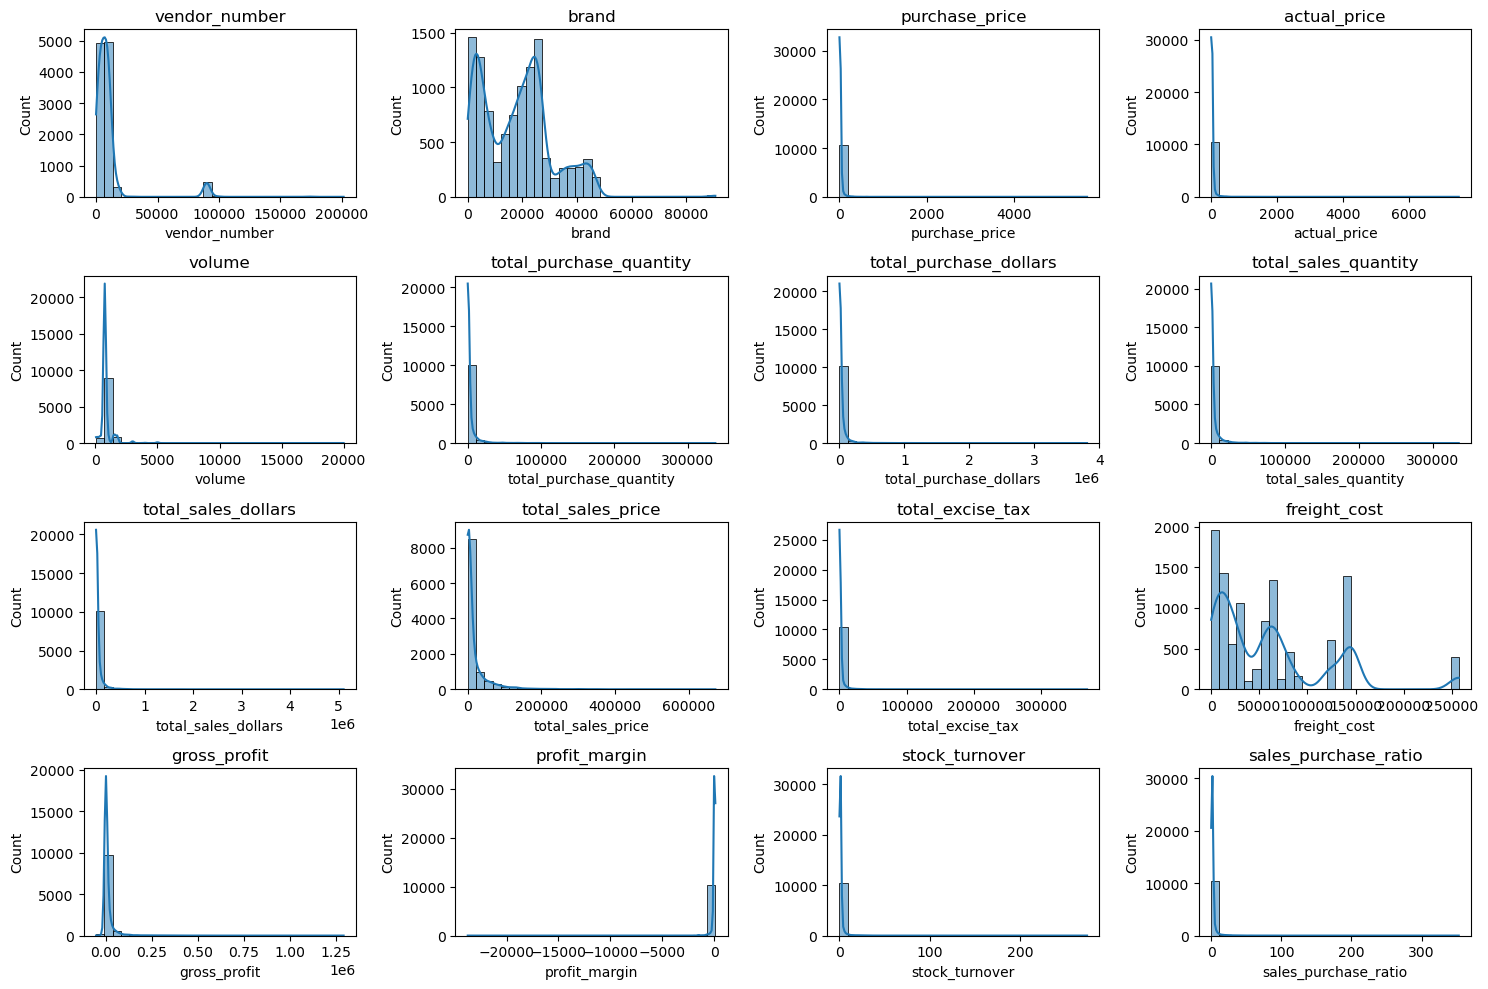

In [4]:
# Distribution plot for numberical columns
numerical_cols = df.select_dtypes(include = np.number).columns

plt.figure(figsize = (15,10))
for i ,col in enumerate(numerical_cols):
    plt.subplot(4,4,i+1) # Adjust grid layout as needed
    sns.histplot(df[col],kde = True , bins = 30)
    plt.title(col)
plt.tight_layout()
plt.show()

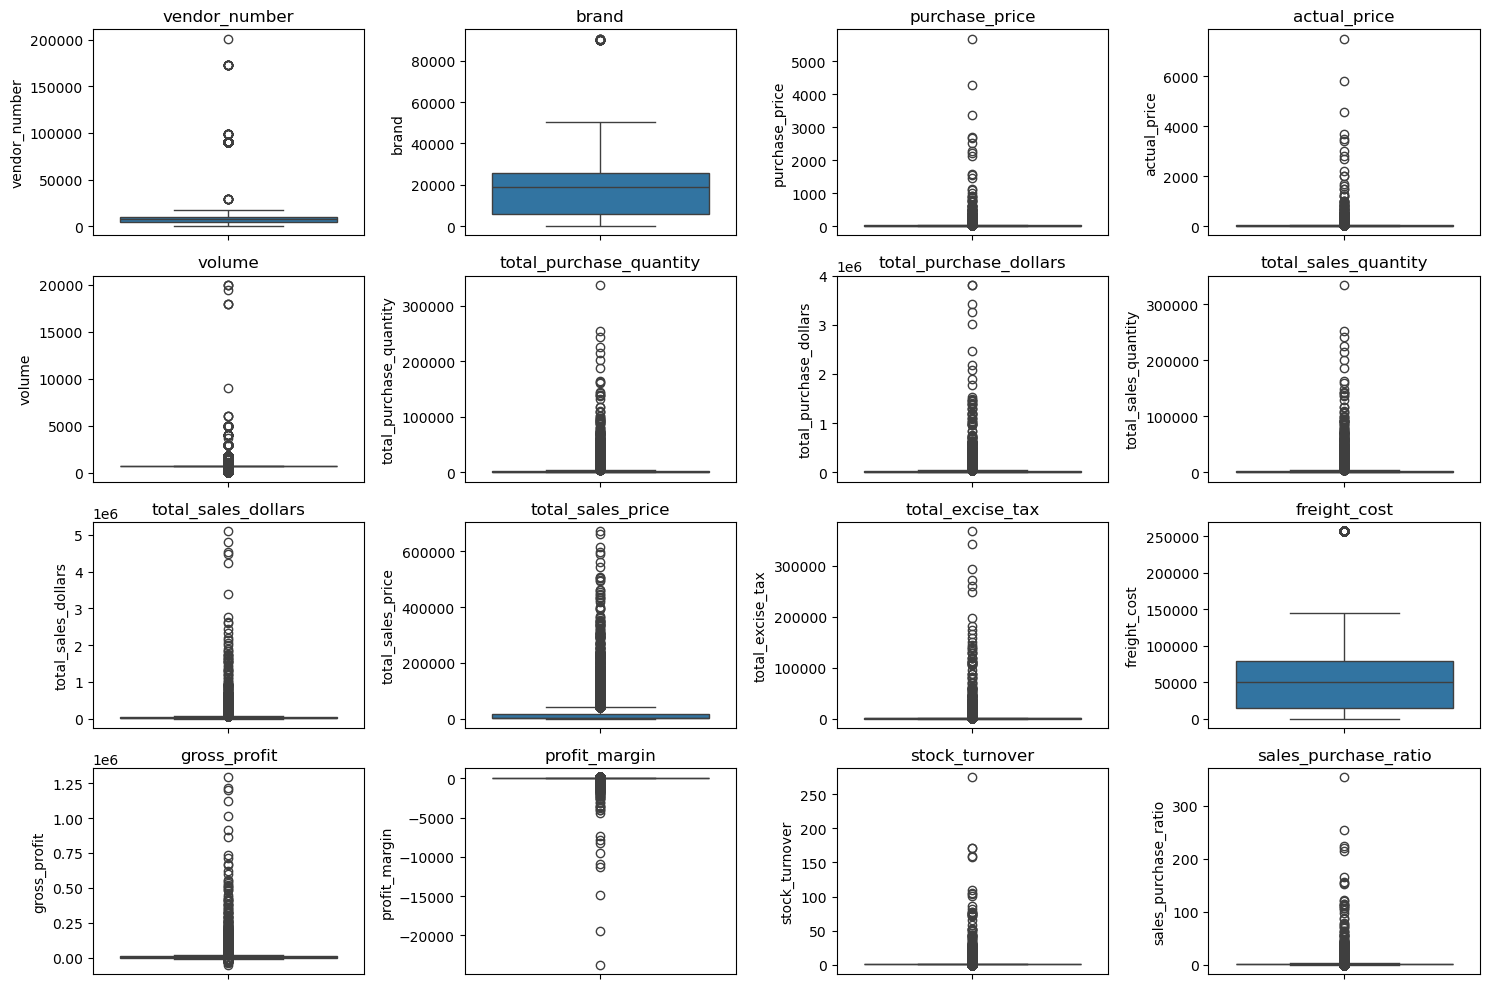

In [5]:
#outlier detection with boxplots
plt.figure(figsize = (15,10))
for i ,col in enumerate(numerical_cols):
    plt.subplot(4,4,i+1) # Adjust grid layout as needed
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

### Summary Statistics Insights:
#### Negative & Zero Values:
* Gross profit: Minimum value is less than zero indicating losses. Some products or transactions may be selling at a loss due to high costs or   selling at dicounts lower than the purchase price.
* Profit Margin: Has a minimum of negative infinity value, which suggests cases where revenue is zero or even lower than costs.
* Total Sales Quantity & Sales Dollars: minimum values are 0 , meaning some products were purchased but never sold. These could be slow-moving or obslete stock.
#### Outliers Indicated by High Standard Deviations:
* Purchase & Actual Prices: The max values are significantly higher than the mean, indicating potential premium products.
* Freight cost: Huge variation suggests logistics inefficiencies or bulk shipments.
* Stock Turnover: Ranges from 0 to 274.5, implying some products sell extremely fast while others remain in stock definitely. Value more than 1 indicates that sold quantity for that products is higher than purchased quantity due to either sales are being fulfilled from older stock.

In [5]:
# filtering data by removing inconsistencies
df = pd.read_sql_query("""select * from vendor_sales_summary
where gross_profit >0
and profit_margin > 0
and total_sales_quantity>0""",conn)

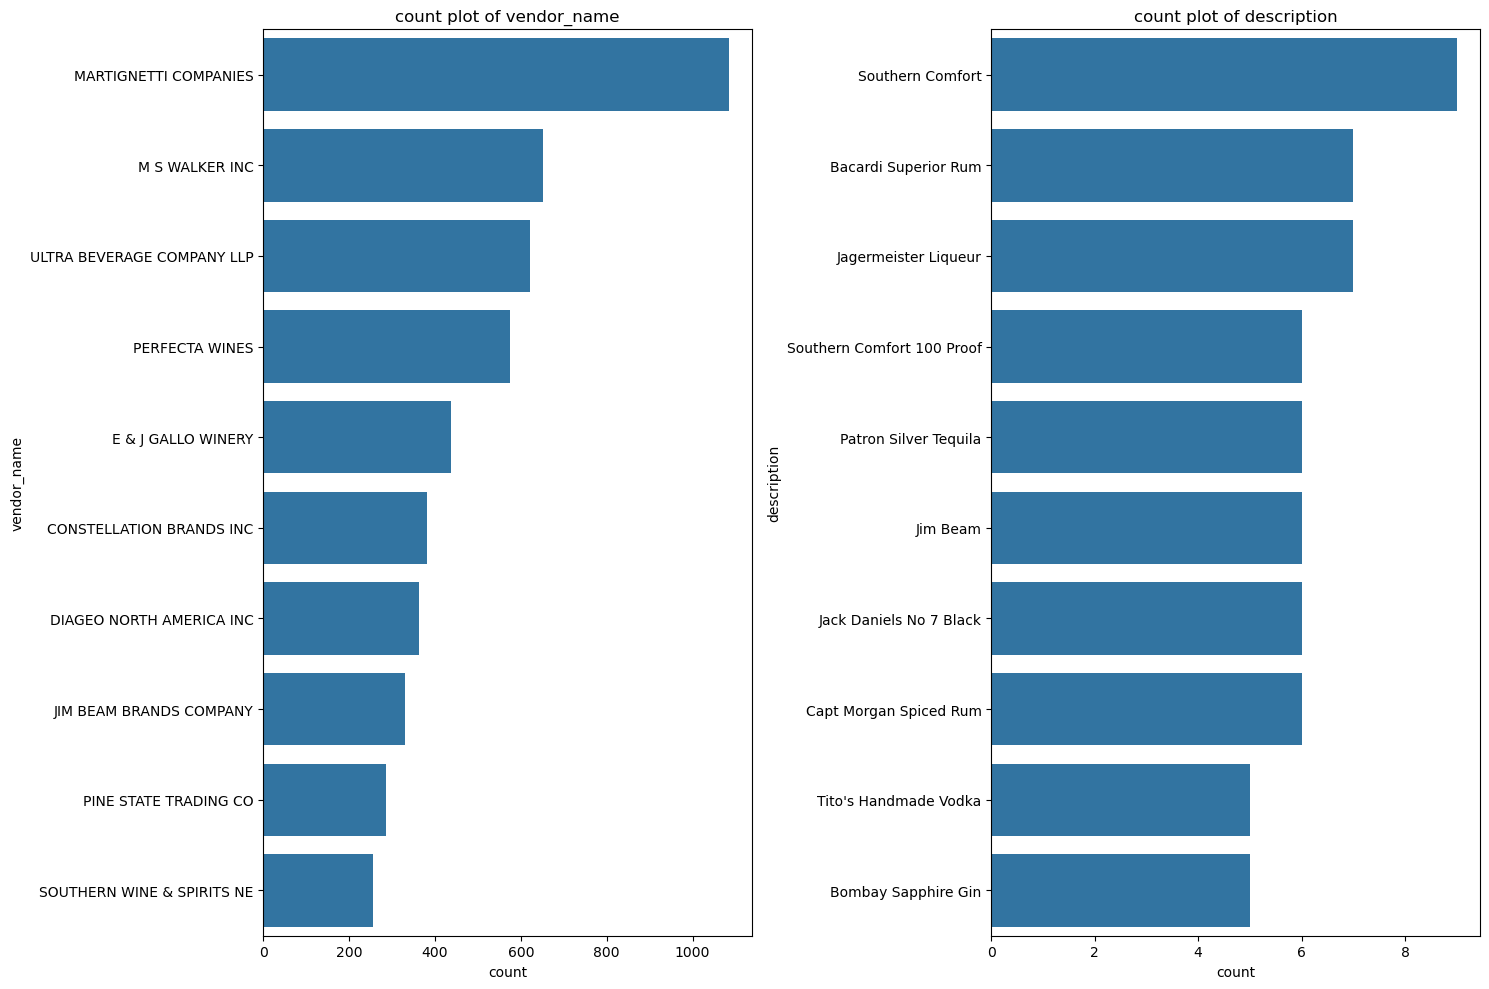

In [6]:
#count plots for categorical columns
categorical_cols = ['vendor_name','description']

plt.figure(figsize = (15,10))
for i ,col in enumerate(categorical_cols):
    plt.subplot(1,2,i+1) # Adjust grid layout as needed
    sns.countplot(y = df[col],order=df[col].value_counts().index[:10]) #top 10 categories
    plt.title(f'count plot of {col}')
plt.tight_layout()
plt.show()

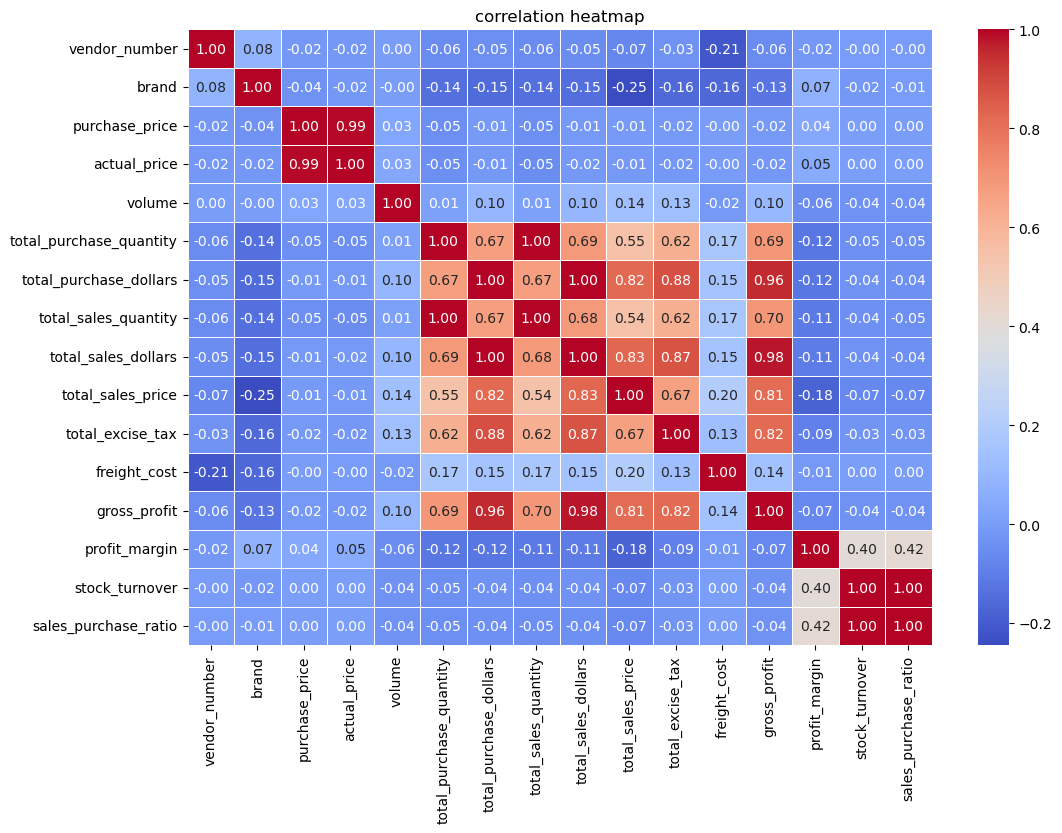

In [7]:
#correlation heatmap
plt.figure(figsize=(12,8))
corr_matrix = df[numerical_cols].corr()
sns.heatmap(corr_matrix,annot = True,fmt = ".2f",cmap="coolwarm",linewidth=0.5)
plt.title("correlation heatmap")
plt.show()

#### Correlation Insights
* Purchase_price has weak correlation with total_sales_dollars(-0.01) and gross_profit(-0.02) , suggesting that price variations do not significantly impact sales revenue or profit
* Strong correlation between total_purchase_quantity and total_sales_quantity, confirming efficient inventory turnover.
* Negative correlation between profit_margin and total_sales_price suggests that as sales_price increases, margins decreases, possibly due to competitive pricing pressures.
* Stock_turnover has weak negative correlations with both gross_profit and profit_margin, indicating that faster turnover does not necessarily result in higher profitability

## Data Analysis

#### Identify Brands that needs promotional or pricing adjustments which exhibit lower sales performance but higher profit margins

In [8]:
brand_performance = df.groupby('description').agg({'total_sales_dollars':'sum', 'profit_margin':'mean'}).reset_index()

In [9]:
brand_performance

,description,total_sales_dollars,profit_margin
0,(RI) 1,21519.09,18.060661
1,.nparalleled Svgn Blanc,1094.63,29.978166
2,10 Span Cab Svgn CC,2703.89,20.937612
3,10 Span Chard CC,3325.56,27.806445
4,10 Span Pnt Gris Monterey Cy,2082.22,32.226182
...,...,...,...
7702,Zorvino Vyds Sangiovese,10579.03,29.525675
7703,Zuccardi Q Malbec,1639.18,23.981503
7704,Zum Rsl,10857.34,32.675038
7705,Zwack Liqueur,227.88,16.653502


In [10]:
low_sales_threshold= brand_performance['total_sales_dollars'].quantile(0.15)
high_margin_threshold= brand_performance['profit_margin'].quantile(0.85)

In [11]:
# Filter brands with low sales but high profit margins
target_brands = brand_performance[(brand_performance['total_sales_dollars'] <= low_sales_threshold) &
                                   (brand_performance['profit_margin'] >= high_margin_threshold)]
print("brands with low sales but high profit margin:")
display(target_brands.sort_values('total_sales_dollars'))

brands with low sales but high profit margin:


,description,total_sales_dollars,profit_margin
6199,Santa Rita Organic Svgn Bl,9.99,66.466466
2369,Debauchery Pnt Nr,11.58,65.975820
2070,Concannon Glen Ellen Wh Zin,15.95,83.448276
2188,Crown Royal Apple,27.86,89.806174
6237,Sauza Sprklg Wild Berry Marg,27.96,82.153076
...,...,...,...
5074,Nanbu Bijin Southern Beauty,535.68,76.747312
2271,Dad's Hat Rye Whiskey,538.89,81.851584
57,A Bichot Clos Marechaudes,539.94,67.740860
6245,Sbragia Home Ranch Merlot,549.75,66.444748


In [12]:
brand_performance = brand_performance[brand_performance['total_sales_dollars']<10000]

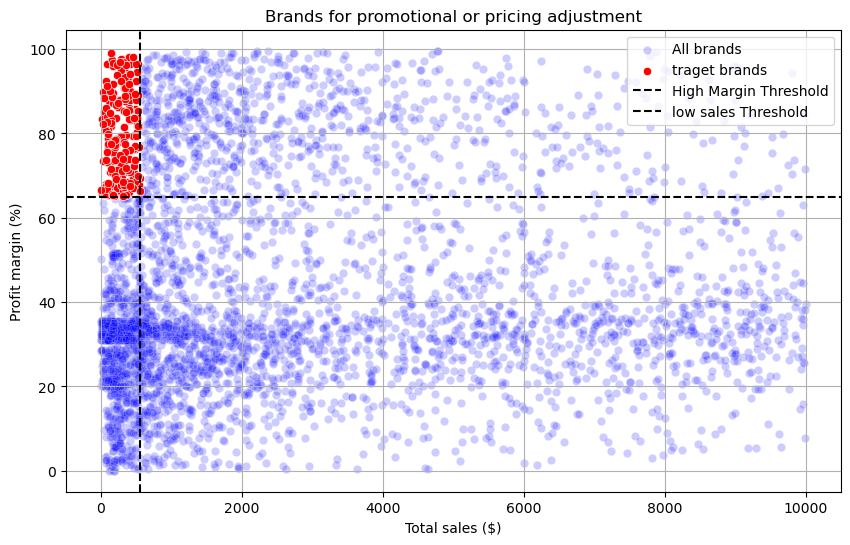

In [13]:
plt.figure(figsize = (10,6))
sns.scatterplot(data = brand_performance, x = 'total_sales_dollars',y='profit_margin',color='blue',label='All brands',alpha = 0.2)
sns.scatterplot(data = target_brands, x = 'total_sales_dollars',y='profit_margin',color='red',label='traget brands')

plt.axhline(high_margin_threshold,linestyle = '--',color = 'black',label = 'High Margin Threshold')
plt.axvline(low_sales_threshold,linestyle = '--',color = 'black',label = 'low sales Threshold')

plt.xlabel('Total sales ($)')
plt.ylabel('Profit margin (%)')
plt.title('Brands for promotional or pricing adjustment')
plt.legend()
plt.grid(True)
plt.show()

####  Which vendors and brands demonstrate the highest sales performance ?

In [14]:
def format_dollars(value):
    if value >= 1_000_000:
        return f'{value / 1_000_000: .2f} M'
    elif value >= 1_000:
        return f'{value / 1_000: .2f} K'
    else:
        return str(value)

In [15]:
# Top vendors and brand by sales performance
top_vendors = df.groupby('vendor_name')['total_sales_dollars'].sum().nlargest(10)
top_brands = df.groupby('description')['total_sales_dollars'].sum().nlargest(10)

In [16]:
top_vendors

vendor_name
DIAGEO NORTH AMERICA INC      67990099.42
MARTIGNETTI COMPANIES         39330359.36
PERNOD RICARD USA             32063196.19
JIM BEAM BRANDS COMPANY       31423020.46
BACARDI USA INC               24854817.14
CONSTELLATION BRANDS INC      24218745.65
E & J GALLO WINERY            18399899.46
BROWN-FORMAN CORP             18247230.65
ULTRA BEVERAGE COMPANY LLP    16502544.31
M S WALKER INC                14706458.51
Name: total_sales_dollars, dtype: float64

In [17]:
top_brands.apply(lambda x: format_dollars(x))

description
Jack Daniels No 7 Black     7.96 M
Tito's Handmade Vodka       7.40 M
Grey Goose Vodka            7.21 M
Capt Morgan Spiced Rum      6.36 M
Absolut 80 Proof            6.24 M
Jameson Irish Whiskey       5.72 M
Ketel One Vodka             5.07 M
Baileys Irish Cream         4.15 M
Kahlua                      3.60 M
Tanqueray                   3.46 M
Name: total_sales_dollars, dtype: object

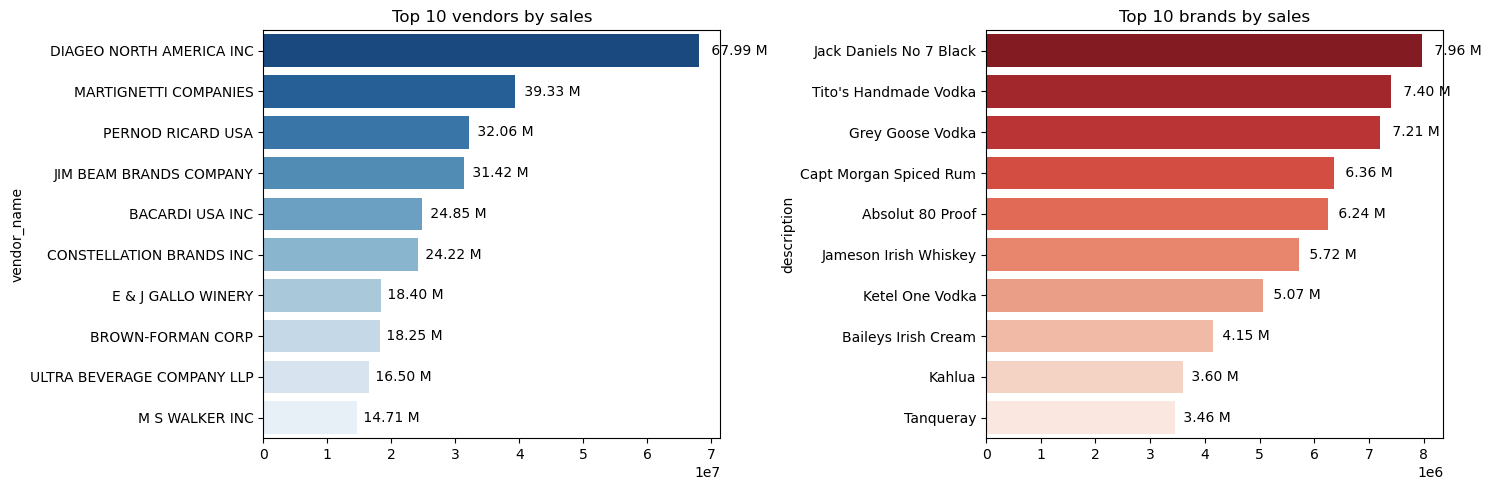

In [18]:
plt.figure(figsize = (15,5))

#Plot for top vendors
plt.subplot(1,2,1)
ax1 = sns.barplot(y = top_vendors.index, x = top_vendors.values, palette = 'Blues_r')
plt.title('Top 10 vendors by sales')

for bar in ax1.patches:
    ax1.text(bar.get_width() + (bar.get_width()*0.02),
             bar.get_y() + bar.get_height()/2,
             format_dollars(bar.get_width()),
             ha ='left',va='center',fontsize=10 ,color='black')

#Plot for top brands
plt.subplot(1,2,2)
ax2 = sns.barplot(y = top_brands.index.astype(str), x = top_brands.values, palette = 'Reds_r')
plt.title('Top 10 brands by sales')

for bar in ax2.patches:
    ax2.text(bar.get_width() + (bar.get_width()*0.02),
             bar.get_y() + bar.get_height()/2,
             format_dollars(bar.get_width()),
             ha='left',va='center',fontsize=10 ,color='black')

plt.tight_layout()
plt.show()

### Which vendors contribute the most to total purchase dollars?

In [19]:
vendor_performance = df.groupby('vendor_name').agg({
    'total_purchase_dollars':'sum',
    'gross_profit':'sum',
    'total_sales_dollars':'sum'}).reset_index()

In [39]:
vendor_performance['purchase_contribution%'] = vendor_performance['total_purchase_dollars']/vendor_performance['total_purchase_dollars'].sum()*100

In [40]:
vendor_performance

,vendor_name,total_purchase_dollars,gross_profit,total_sales_dollars,purchase_contribution%
25,DIAGEO NORTH AMERICA INC,50097226.16,17892873.26,67990099.42,16.300345
57,MARTIGNETTI COMPANIES,25502095.83,13828263.53,39330359.36,8.297724
68,PERNOD RICARD USA,23851164.17,8212032.02,32063196.19,7.760554
46,JIM BEAM BRANDS COMPANY,23494304.32,7928716.14,31423020.46,7.644441
6,BACARDI USA INC,17432020.26,7422796.88,24854817.14,5.671930
...,...,...,...,...,...
33,FANTASY FINE WINES CORP,128.64,198.95,327.59,0.000042
107,UNCORKED,118.74,58.20,176.94,0.000039
85,SILVER MOUNTAIN CIDERS,77.18,265.33,342.51,0.000025
16,CAPSTONE INTERNATIONAL,54.64,192.23,246.87,0.000018


In [41]:
vendor_performance = round(vendor_performance.sort_values('purchase_contribution%',ascending = False),2)

In [42]:
# Display top 10 vendors
top_vendors = vendor_performance.head(10)
top_vendors['total_purchase_dollars'] = top_vendors['total_purchase_dollars'].apply(format_dollars)
top_vendors['total_sales_dollars'] = top_vendors['total_sales_dollars'].apply(format_dollars)
top_vendors['gross_profit'] = top_vendors['gross_profit'].apply(format_dollars)
top_vendors

,vendor_name,total_purchase_dollars,gross_profit,total_sales_dollars,purchase_contribution%
25,DIAGEO NORTH AMERICA INC,50.10 M,17.89 M,67.99 M,16.30
57,MARTIGNETTI COMPANIES,25.50 M,13.83 M,39.33 M,8.30
68,PERNOD RICARD USA,23.85 M,8.21 M,32.06 M,7.76
46,JIM BEAM BRANDS COMPANY,23.49 M,7.93 M,31.42 M,7.64
6,BACARDI USA INC,17.43 M,7.42 M,24.85 M,5.67
20,CONSTELLATION BRANDS INC,15.27 M,8.95 M,24.22 M,4.97
11,BROWN-FORMAN CORP,13.24 M,5.01 M,18.25 M,4.31
30,E & J GALLO WINERY,12.07 M,6.33 M,18.40 M,3.93
106,ULTRA BEVERAGE COMPANY LLP,11.17 M,5.34 M,16.50 M,3.63
53,M S WALKER INC,9.76 M,4.94 M,14.71 M,3.18


In [43]:
top_vendors['purchase_contribution%'].sum()

np.float64(65.69000000000001)

In [44]:
top_vendors['cumulative_contribution%']= top_vendors['purchase_contribution%'].cumsum()
top_vendors

,vendor_name,total_purchase_dollars,gross_profit,total_sales_dollars,purchase_contribution%,cumulative_contribution%
25,DIAGEO NORTH AMERICA INC,50.10 M,17.89 M,67.99 M,16.30,16.30
57,MARTIGNETTI COMPANIES,25.50 M,13.83 M,39.33 M,8.30,24.60
68,PERNOD RICARD USA,23.85 M,8.21 M,32.06 M,7.76,32.36
46,JIM BEAM BRANDS COMPANY,23.49 M,7.93 M,31.42 M,7.64,40.00
6,BACARDI USA INC,17.43 M,7.42 M,24.85 M,5.67,45.67
20,CONSTELLATION BRANDS INC,15.27 M,8.95 M,24.22 M,4.97,50.64
11,BROWN-FORMAN CORP,13.24 M,5.01 M,18.25 M,4.31,54.95
30,E & J GALLO WINERY,12.07 M,6.33 M,18.40 M,3.93,58.88
106,ULTRA BEVERAGE COMPANY LLP,11.17 M,5.34 M,16.50 M,3.63,62.51
53,M S WALKER INC,9.76 M,4.94 M,14.71 M,3.18,65.69


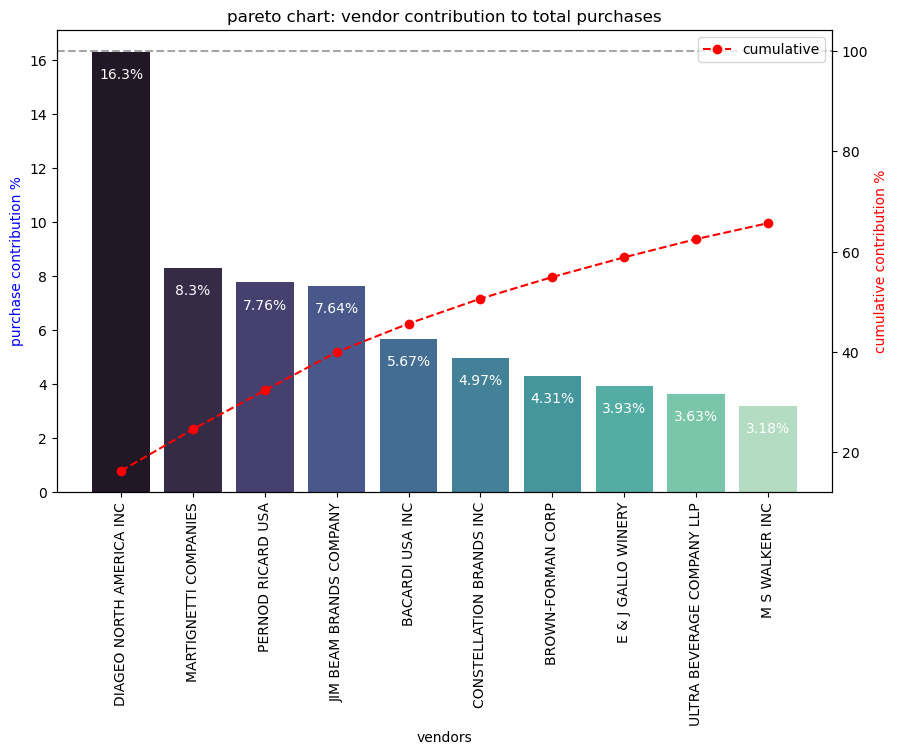

In [45]:
fig , ax1 = plt.subplots(figsize = (10,6))

# Bar plot for purchase contribution%
sns.barplot(x=top_vendors['vendor_name'],y=top_vendors['purchase_contribution%'],palette= 'mako',ax=ax1)

for i,value in enumerate(top_vendors['purchase_contribution%']):
    ax1.text(i,value - 1,str(value)+'%',ha ='center',fontsize=10,color = 'white')

# Line plot for cumulative contribution%
ax2= ax1.twinx()
ax2.plot(top_vendors['vendor_name'],top_vendors['cumulative_contribution%'],color='red',marker='o',linestyle='dashed',label= 'cumulative')

ax1.set_xticklabels(top_vendors['vendor_name'],rotation=90)
ax1.set_ylabel('purchase contribution %',color = 'blue')
ax2.set_ylabel('cumulative contribution %',color = 'red')   
ax1.set_xlabel('vendors')
ax1.set_title('pareto chart: vendor contribution to total purchases')

ax2.axhline(y=100,color='gray',linestyle='dashed',alpha=0.7)
ax2.legend(loc='upper right')

plt.show()

### How much of total procurement is dependent on the top vendors ?

In [46]:
print(f'Total purchase contribution of top 10 vendors is {round(top_vendors['purchase_contribution%'].sum(),2)} %')

Total purchase contribution of top 10 vendors is 65.69 %


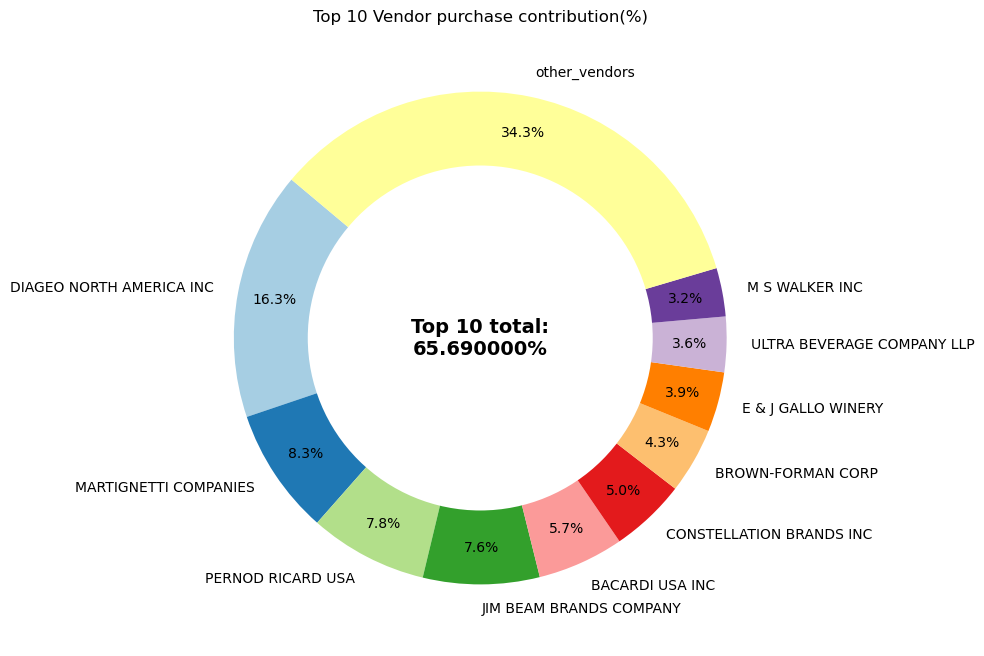

In [47]:
vendors = list(top_vendors['vendor_name'].values)
purchase_contributions = list(top_vendors['purchase_contribution%'].values)
total_contribution = sum(purchase_contributions)
remaining_contribution = 100-total_contribution

#Append 'other vendors' category
vendors.append('other_vendors')
purchase_contributions.append(remaining_contribution)

# Donut chart
fig,ax = plt.subplots(figsize=(8,8))
wedges,texts,autotexts = plt.pie(purchase_contributions, labels = vendors ,autopct = '%1.1f%%', 
                                startangle = 140, pctdistance = 0.85 , colors = plt.cm.Paired.colors)

# Draw white circle in the centre to create a 'donut' effect
centre_circle = plt.Circle((0,0),0.70, fc ='white')
fig.gca().add_artist(centre_circle)

# Add total contribution annotation in the centre
plt.text(0,0,f'Top 10 total:\n{total_contribution:2f}%',fontsize = 14 ,fontweight = 'bold', ha = 'center',va='center')

plt.title('Top 10 Vendor purchase contribution(%)')

plt.show()

### Does bulk purchasing reduce the unit price and what is the optimal purchase volume for cost savings?

In [48]:
df['unit_purchase_price'] = df['total_purchase_dollars']/df['total_purchase_quantity']

In [49]:
df['order_size'] = pd.qcut(df['total_purchase_quantity'],q=3,labels = ['small','medium','large'])

In [50]:
df.groupby('order_size')[['unit_purchase_price']].mean()

,unit_purchase_price
order_size,
small,39.068186
medium,15.486414
large,10.777625


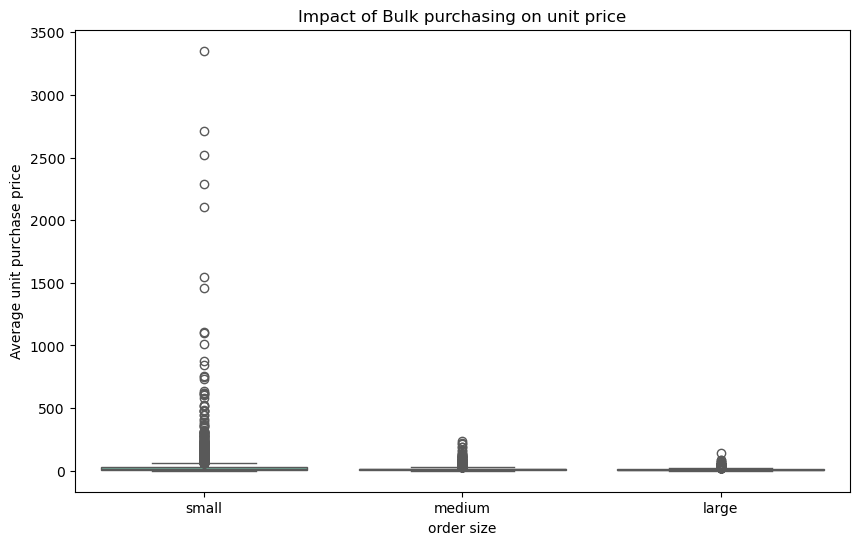

In [51]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df,x='order_size',y='unit_purchase_price',palette='Set2')
plt.title('Impact of Bulk purchasing on unit price')
plt.xlabel('order size')
plt.ylabel('Average unit purchase price')
plt.show()

* Vendors buying in bulk(Large order size) get the lowest unit price , meaning higher margins if they can manage inventory efficiently.
* The price difference between small and large order is substantial(~72% reduction in unit cost)
* This suggests that bulk pricing strategies successfully encourage vendors to purchase in large volumes , leading to higher overall sales despite lower per-unit revenue.

### Which vendors have low inventory turnover,indicating excess stock and slow-moving products?

In [52]:
df[df['stock_turnover']<1].groupby('vendor_name')[['stock_turnover']].mean().sort_values('stock_turnover',ascending = True).head(10)

,stock_turnover
vendor_name,
ALISA CARR BEVERAGES,0.615385
HIGHLAND WINE MERCHANTS LLC,0.708333
PARK STREET IMPORTS LLC,0.751306
Circa Wines,0.755676
Dunn Wine Brokers,0.766022
CENTEUR IMPORTS LLC,0.773953
SMOKY QUARTZ DISTILLERY LLC,0.783835
TAMWORTH DISTILLING,0.797078
THE IMPORTED GRAPE LLC,0.807569


### How much capital is locked in unsold inventory, and which vendors contribute the most of it?

In [53]:
df['unsold_inventory_value'] = (df['total_purchase_quantity']-df['total_sales_quantity'])*df['purchase_price']
print('Total unsold capital:', format_dollars(df['unsold_inventory_value'].sum()))

Total unsold capital:  2.71 M


In [55]:
# Aggregate capital locked per vendor
inventory_value_per_vendor = df.groupby('vendor_name')['unsold_inventory_value'].sum().reset_index()

# sort vendors with the highest locked capital
inventory_value_per_vendor = inventory_value_per_vendor.sort_values(by = 'unsold_inventory_value',ascending=False)
inventory_value_per_vendor['unsold_inventory_value'] = inventory_value_per_vendor['unsold_inventory_value'].apply(format_dollars)
inventory_value_per_vendor.head(10)

,vendor_name,unsold_inventory_value
25,DIAGEO NORTH AMERICA INC,722.21 K
46,JIM BEAM BRANDS COMPANY,554.67 K
68,PERNOD RICARD USA,470.63 K
116,WILLIAM GRANT & SONS INC,401.96 K
30,E & J GALLO WINERY,228.28 K
79,SAZERAC CO INC,198.44 K
11,BROWN-FORMAN CORP,177.73 K
20,CONSTELLATION BRANDS INC,133.62 K
61,MOET HENNESSY USA INC,126.48 K
77,REMY COINTREAU USA INC,118.60 K


In [5]:
df.to_csv('vendor_sales_summary.csv',index= False,float_format='%.4f')